# Intelligent Fault Diagnosis Tutorial

_By the Aalto University ARotor Laboratory (Aleksanteri Hämäläinen & Aku Karhinen)_


In [1]:
## FIXME: Remove this

%load_ext autoreload
%autoreload 2

In [2]:
## Do not edit this cell

import math
import matplotlib.pyplot as plt
import numpy as np

import torch

import xgboost as xgb

import tqdm
import sklearn

# await __import__("piplite").install("openconmo", deps=False)
from openconmo.benchmark_methods import DRS
from openconmo.utils import bandpass_filter, oneside_fft

import signal_processing
from utils import (
    HiddenPrints,
    import_polito,
    plot_confusion_matrix,
    polito_to_sklearn_format,
    squared_envelope,
)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/hamalaa14/.local/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/hamalaa14/.local/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/hamalaa14/.local/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/Users/h

## Dataset setup

We will use bearing fault data from the [Politecnico Di Torino test rig](https://doi.org/10.5281/zenodo.13913254). Details of the test rig can be found in [this paper](https://doi.org/10.3390/machines10010054).

Each measurement is specified by `class`, `rpm`, `radial_force`, and `axial_force`. Note that these are nominal values and do not exactly match the true values.

| Variable     | Options                                                       |
| ------------ | ------------------------------------------------------------- |
| Class        | (H) Healthy, (IR) Inner Race Damage, (OR) Outer Race Damage   |
| RPM          | 523 rpm, 937 rpm                                              |
| Radial force | 62.4 kN, 124.8 kN                                             |
| Axial force  | 0 kN, 49 kN (Not for measurements with radial load = 62.4 kN) |


In [3]:
## Do not edit this cell

# Import dataset
# Bearing with index 3 is the bearing faults are located on
# Measurements are all cut to 30 seconds to get a consistent dataset, because some are 60 seconds and some 30 seconds
polito_dataset, fs, frs = import_polito(bearing_index=3, measurement_max_len=30)

Dataset size: 18 measurements
Measurement duration: 30.0 s
Sampling frequency (fs): 20.48 kHz
Rotating frequencies (frs):
  Nominal 523 rpm, true 505.49 rpm = 8.42 Hz
  Nominal 937 rpm, true 917.17 rpm = 15.29 Hz


Table 1: Bearing Fault Frequency Formulas

| Fault Frequency Name                | Formula                                                                           |
| :---------------------------------- | :-------------------------------------------------------------------------------- |
| **Ball pass frequency, outer race** | $BPFO = \frac{nf_r}{2} \left( 1 - \frac{d}{D} \cos \phi \right)$                  |
| **Ball pass frequency, inner race** | $BPFI = \frac{nf_r}{2} \left( 1 + \frac{d}{D} \cos \phi \right)$                  |
| **Fundamental train frequency**     | $FTF = \frac{f_r}{2} \left( 1 - \frac{d}{D} \cos \phi \right)$                    |
| **Ball (roller) spin frequency**    | $BSF = \frac{Df_r}{2d} \left( 1 - \left[ \frac{d}{D} \cos \phi \right]^2 \right)$ |

- $n$ = Number of rolling elements
- $f_r$ = Shaft rotation frequency
- $d$ = Rolling element diameter
- $D$ = Bearing pitch diameter
- $\phi$ = Angle of the load from the radial plane

Table 2: Polito test rig characteristic frequencies
| Characteristic | Frequency Value (Hz)|
| :--- | :--- |
| Ball Pass Frequency Outer Race, BPFO | $8.176 \times f_r$ |
| Ball Pass Frequency Inner Race, BPFI | $10.824 \times f_r$ |
| Ball Spin Frequency, BSF | $3.464 \times f_r$ |
| Fundamental Train Frequency, FTF | $0.43 \times f_r$ |


In [4]:
## Do not edit this cell

# Multiply the rotating frequencies by these factors to get the characteristic fault frequencies
BPFO_multiplier = 8.176
BPFI_multiplier = 10.824

print("Characteristic fault frequencies at the two included speeds:")
print(
    "(Approximate, because the rotational speeds change slightly between measurements)"
)
print()
for k, v in frs.items():
    print(f"{k} rpm")
    print(f" BPFO: ~{v * BPFO_multiplier:.1f} Hz")
    print(f" BPFI: ~{v * BPFI_multiplier:.1f} Hz")

Characteristic fault frequencies at the two included speeds:
(Approximate, because the rotational speeds change slightly between measurements)

523 rpm
 BPFO: ~68.9 Hz
 BPFI: ~91.2 Hz
937 rpm
 BPFO: ~125.0 Hz
 BPFI: ~165.5 Hz


### Visualize measurements

Visualizing your data is an important step to verify that you are actually working with the data you think you are. It is also a good way to notice possible anomalities in the data, such as interference, broken sensors, mislabeled files, encoders running the wrong way, weird amplitude differences, etc.

Below, we plot 0.5 seconds from each measurement. Feel free to uncomment the lines with different signal analysis methods from OpenConMo to view the data in different ways.


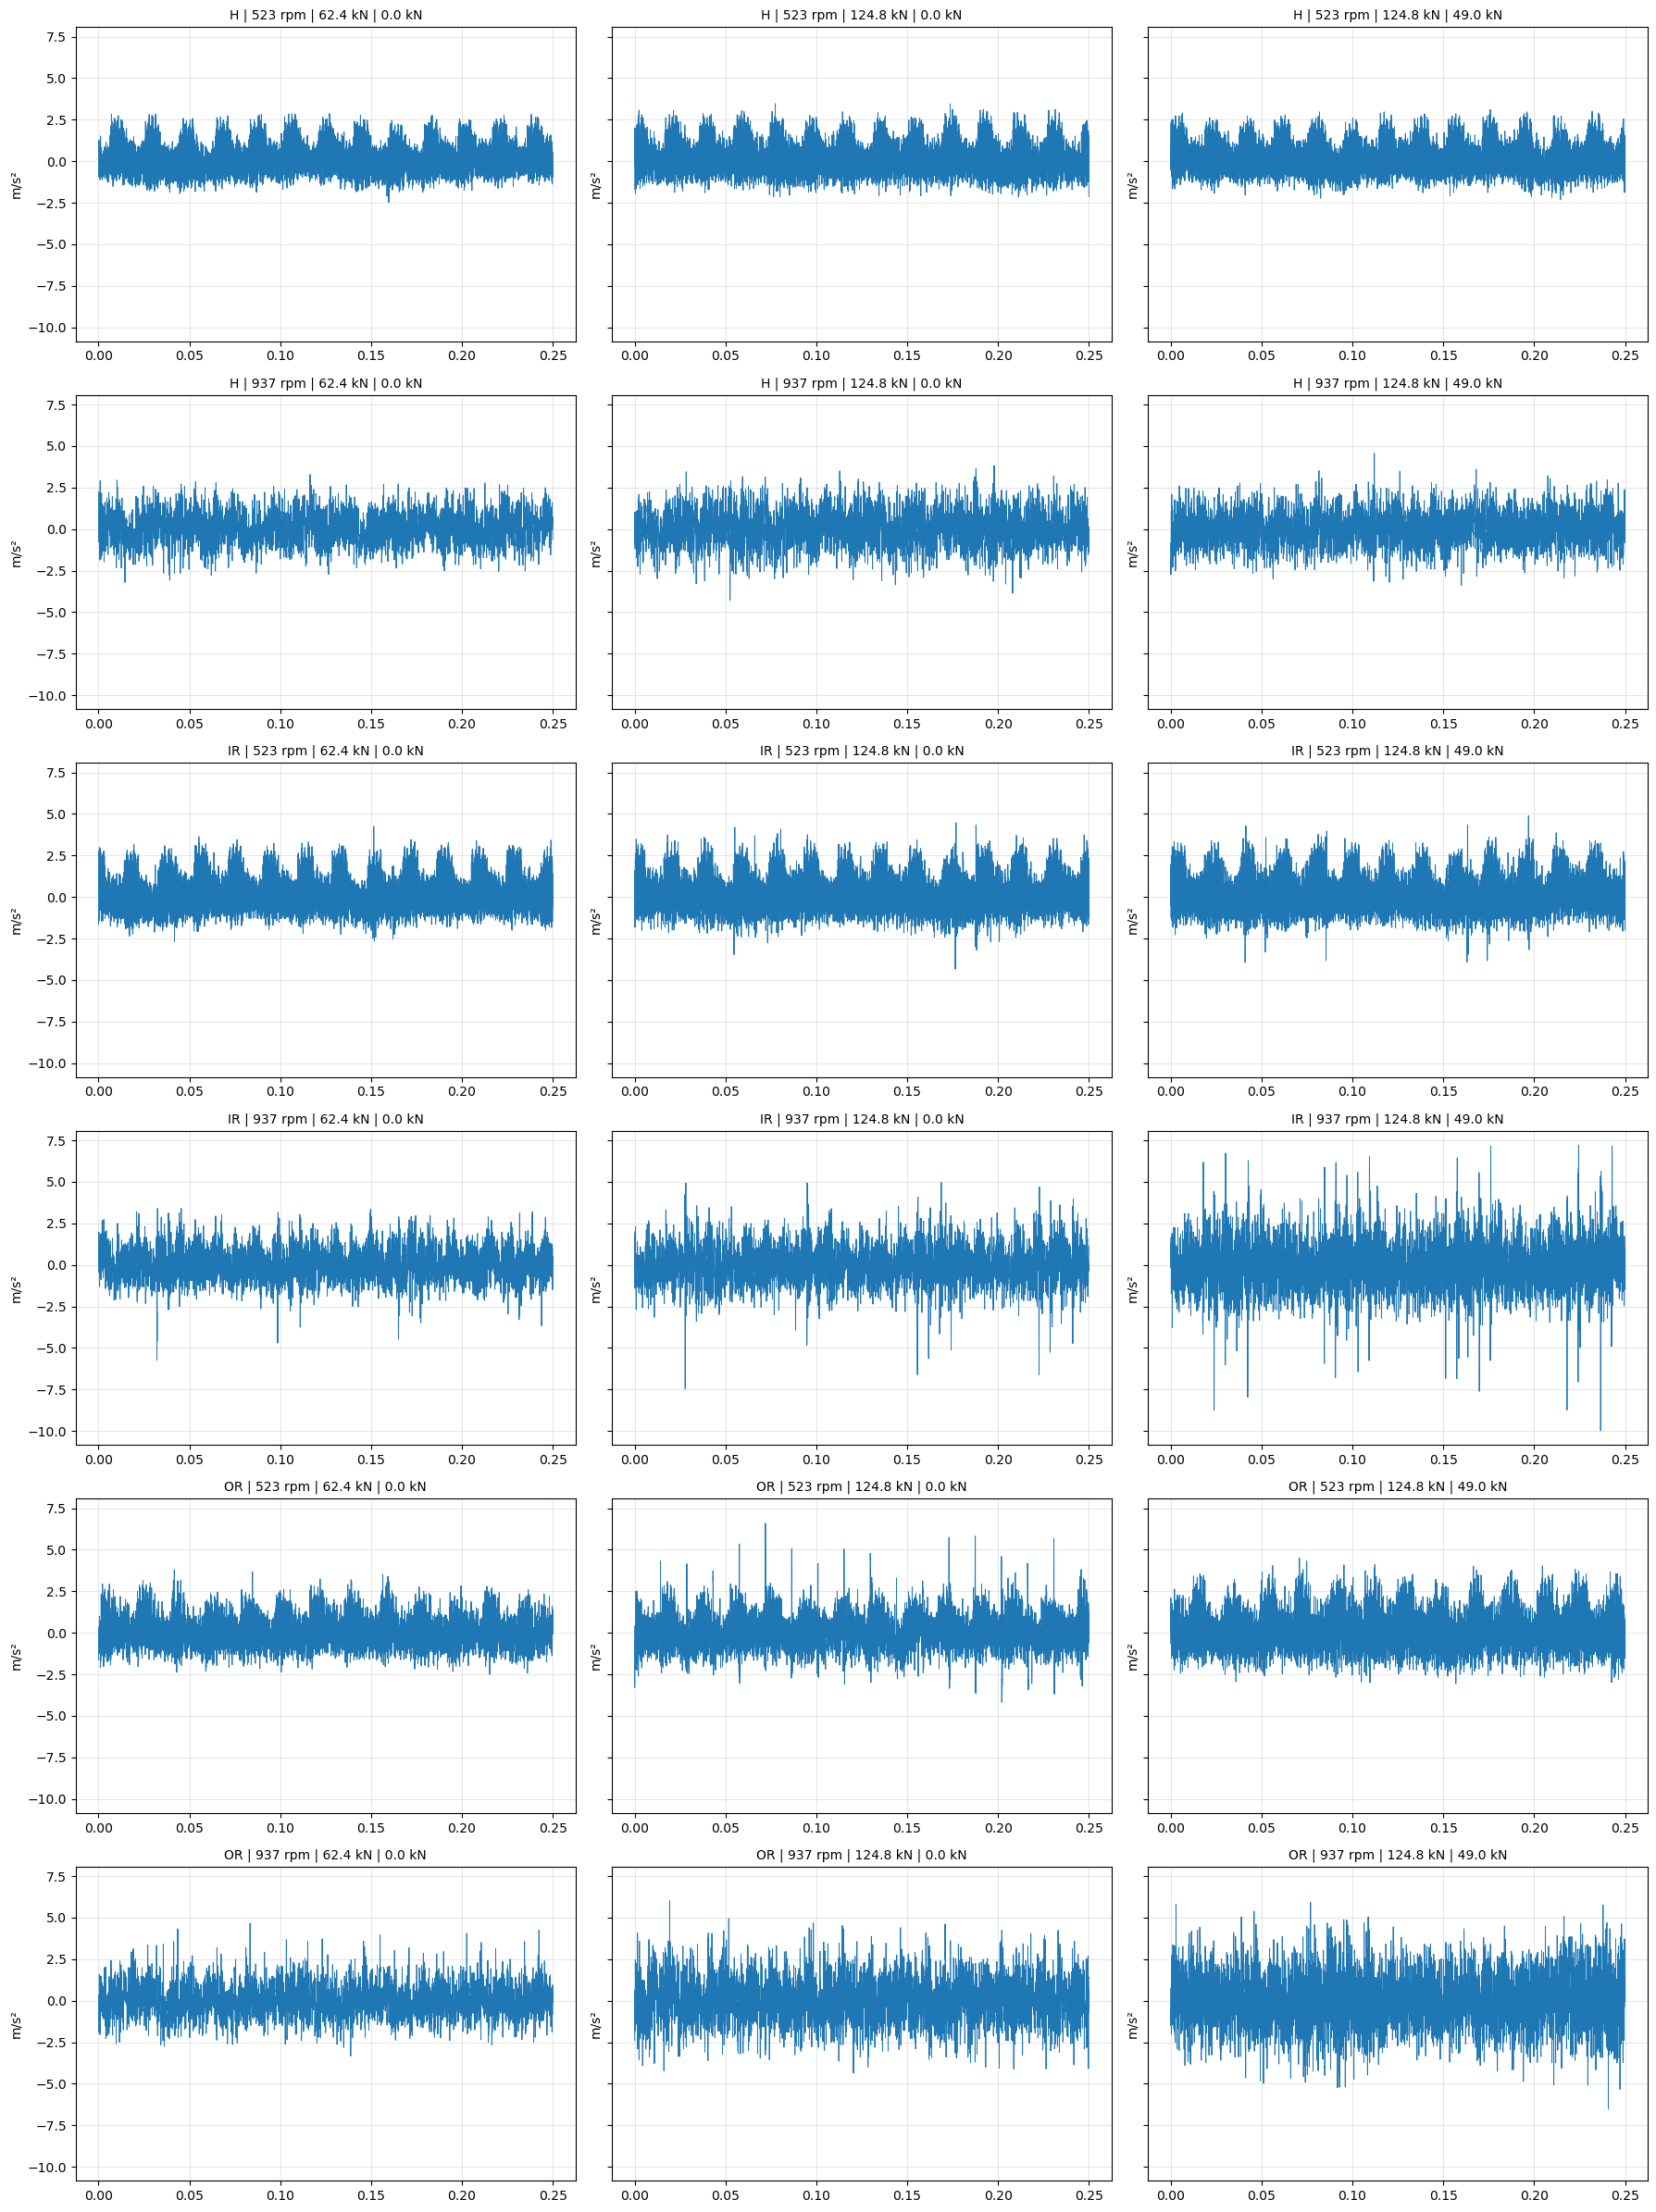

In [5]:
# Sort the dataset by class
signals = sorted(polito_dataset.items(), key=lambda kv: kv[0])

# Plotting stuff
n = len(signals)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(18, 4 * nrows), sharex=False, sharey=True
)
axes = np.atleast_1d(axes).ravel()

# Loop through all measurements
for ax, (key, signal) in zip(axes, signals):
    class_label, rpm, radial_force, axial_force = key

    # Preprocess signal #

    ## HERE:  Optionally, plot the random (or discrete) part of the DRS
    # signal, signal_discrete = DRS(signal, 3000, 12_000)

    # HERE: Optionally, bandpass filter the signal
    # signal = bandpass_filter(signal, fs, 3000, 1200)

    ## HERE: Optionally, plot the squared envelope
    # signal = squared_envelope(signal)

    # Cut signal to make it easier to see the details
    signal = signal[2 * fs : 2 * fs + (fs // 4)]
    x = np.arange(len(signal)) / fs

    ## HERE: Optionally, plot the spectrum
    # x = np.fft.rfftfreq(len(signal), 1/fs)[1:]
    # signal = np.abs(np.fft.rfft(signal))[1:]

    # Plot #

    ax.plot(x, signal, linewidth=0.7)
    ax.set_title(
        f"{class_label} | {rpm} rpm | {radial_force} kN | {axial_force} kN", fontsize=10
    )
    ax.grid(True, alpha=0.3)
    ax.set_ylabel("m/s²")

plt.tight_layout()
plt.show()

Below, you can view a single signal in more detail.


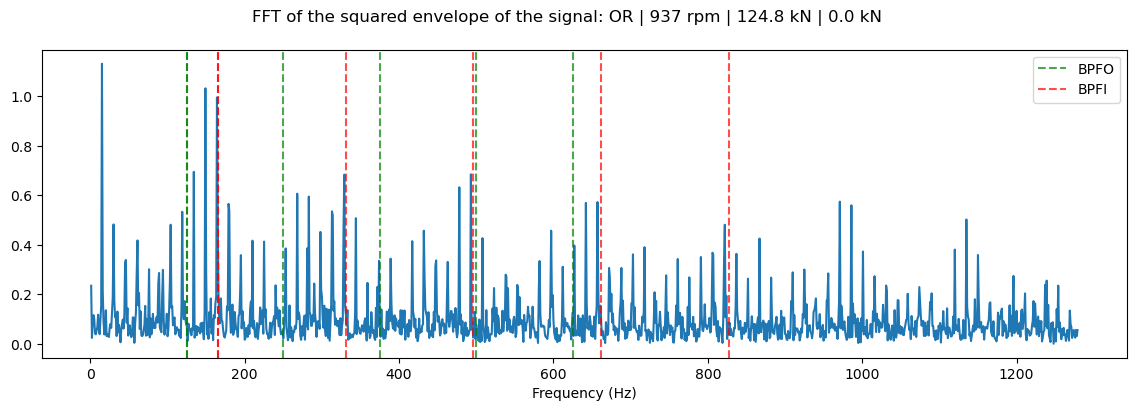

In [6]:
# HERE: You can change which signal to plot
fault_vis = "IR"  # H/OR/IR # H = Healthy, OR = Outer ring fault, IR = Inner ring fault
rpm_vis = 937  # 523/937
radial_force_vis = 124.8  # 62.4/124.8
axial_force_vis = 0.0  # 0.0/49.0

# Get measurement
s1 = polito_dataset[(fault_vis, rpm_vis, radial_force_vis, axial_force_vis)]

# Preprocess signal
# HERE: Add DRS or a bandpass filter if you want
# s1, s1_discrete = DRS(s1, 3000, 12_000)
# s1 = bandpass_filter(s1, fs, 3000, 1500)
s1 = squared_envelope(s1[:fs])  # Keep only the first second
f, X = oneside_fft(s1, fs)

# Plot
plt.figure(figsize=(14, 4))
plt.suptitle(
    f"FFT of the squared envelope of the signal: {class_label} | {rpm_vis} rpm | {radial_force_vis} kN | {axial_force_vis} kN"
)
plt.xlabel("Frequency (Hz)")
plt.plot(f[1 : len(f) // 8], X[1 : len(f) // 8])

for i in range(1, 6):
    if i == 1:
        plt.axvline(
            frs[rpm_vis] * BPFO_multiplier * i,
            color="g",
            linestyle="--",
            alpha=0.7,
            label="BPFO",
        )
        plt.axvline(
            frs[rpm_vis] * BPFI_multiplier * i,
            color="r",
            linestyle="--",
            alpha=0.7,
            label="BPFI",
        )
    plt.axvline(
        frs[rpm_vis] * BPFO_multiplier * i, color="g", linestyle="--", alpha=0.7
    )
    plt.axvline(
        frs[rpm_vis] * BPFI_multiplier * i, color="r", linestyle="--", alpha=0.7
    )
plt.legend()
plt.show()

### Signal Transformations

Depending on the machine, sensors, and ML/DL methods, different types of preprocessing will be appropriate. The cell below lets you choose between DRS, bandpass filtering, and/or using the squared envelope.

Some preprocessing methods, such as DRS, filtering, and square envelope are best applied on full measurements. On the other hand, some preprocessing steps, such as FFT, only make sense after the measurements have been split into samples.


In [7]:
# HERE: You can choose which preprocessing steps to apply by changing the methods argument
polito_dataset_preprocessed = signal_processing.preprocess_signals(
    polito_dataset,
    methods=[
        # "DRS",
        # "bandpass_filter",
        "squared_envelope",
    ],
)
print("Preprocessing applied")

Preprocessing applied


### Convert dataset to Scikit-Learn compatible format

[Scikit-learn](https://scikit-learn.org) is a popular and convenient Python library for machine learning. We will use some classifiers from it here, so let us create training and testing datasets in the appropriate shapes.


In [8]:
# HERE: You can change which measurements to use for training and testing by changing the rpms, radial_forces, and axial_forces arguments
#   RPM options: 523, 937
#   Radial load options (Nm): 62.4, 124.8
#   Axial load options (Nm): 0, 49 (49 Kn only for 124.8 Kn load)

X_train_raw, y_train, X_train_rpm = polito_to_sklearn_format(
    polito_dataset_preprocessed,
    # rpms=[523],
    # rpms=[937],
    radial_forces=[62.4],
    # radial_forces=[124.8],
    axial_forces=[0],
    window_size=20480,
    overlap=0.9,
)
X_test_raw, y_test, X_test_rpm = polito_to_sklearn_format(
    polito_dataset_preprocessed,
    # rpms=[523],
    # rpms=[937],
    radial_forces=[124.8],
    # radial_forces=[62.4],
    axial_forces=[0],
    window_size=20480,
    overlap=0.9,
)

Num samples: 1626, sample size: 20480, class distribution: [542 542 542]
Num samples: 1626, sample size: 20480, class distribution: [542 542 542]


### Feature extraction

Most ML methods work better with extracted features instead of raw signals. In the cell below, you can select from a set of defined methods. You can also define one or more of your own methods.

First however, implement the widely used root mean square yourself. The RMS of a discrete signal \(x\) with \(N\) samples is defined as follows:

$$\mathrm{RMS}(x)=\sqrt{\frac{1}{N}\sum_{n=1}^{N}x_n^2}$$


In [9]:
# CODE HERE
# HINT 1: The input `samples` is of shape [N, window_size] and
#  the output should be shape [N]
# HINT 2: Ignore the `rpms` input!
def rms(samples, rpms):
    return np.sqrt(np.mean(np.square(samples), axis=1))


# CODE HERE: You can define your own feature extractor
# def my_own_feature(samples):
#     return ...  # implement your own feature here


def get_features(samples, rpms, features):
    all_feature_extractors = {
        "mean": signal_processing.mean,
        "rms": rms,
        "variance": signal_processing.variance,
        "skewness": signal_processing.skewness,
        "kurtosis": signal_processing.kurtosis_,
        "peak_to_peak": signal_processing.peak_to_peak,
        "crest_factor": signal_processing.crest_factor,
        "BPFO_1": signal_processing.BPFO_1,
        "BPFO_2": signal_processing.BPFO_2,
        "BPFO_3": signal_processing.BPFO_3,
        "BPFI_1": signal_processing.BPFI_1,
        "BPFI_2": signal_processing.BPFI_2,
        "BPFI_3": signal_processing.BPFI_3,
        # "my_own_feature": my_own_feature,
    }

    # Use specified feature extractors
    new_samples = [all_feature_extractors[key](samples, rpms) for key in features]

    return np.stack(new_samples, axis=1)


# HERE: You can choose which features to use by changing the features_to_use list
features_to_use = [
    "mean",
    "rms",
    "variance",
    "skewness",
    "kurtosis",
    "peak_to_peak",
    "crest_factor",
    # "my_own_feature",
    # "BPFO_1",
    # "BPFO_2",
    # "BPFO_3",
    # "BPFI_1",
    # "BPFI_2",
    # "BPFI_3",
]
X_train = get_features(X_train_raw, X_train_rpm, features_to_use)
X_test = get_features(X_test_raw, X_test_rpm, features_to_use)

# X_test = X_test * 2

print(f"Training set shape before: {X_train_raw.shape}")
print(f"Training set shape after: {X_train_raw.shape}")

Training set shape before: (1626, 20480)
Training set shape after: (1626, 20480)


## Classification

### XGBoost

The first method we will use is [XGBoost](https://xgboost.readthedocs.io). XGBoost has its own library and not from Scikit-learn, but it does provide a [Scikit-Learn estimator interface](https://xgboost.readthedocs.io/en/release_3.2.0/python/sklearn_estimator.html), meaning it can be used very similarly to any other classifiers from Scikit-learn.

XGBoost describes itself as:

> XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible and portable. It implements machine learning algorithms under the Gradient Boosting framework. XGBoost provides a parallel tree boosting (also known as GBDT, GBM) that solve many data science problems in a fast and accurate way. The same code runs on major distributed environment (Hadoop, SGE, MPI) and can solve problems beyond billions of examples.

It is a good baseline for nearly any classification problem when the data is structured or tabular (i.e. not raw time-series or image data).


[0]	validation_0-mlogloss:1.08051
[1]	validation_0-mlogloss:1.07202
[2]	validation_0-mlogloss:1.07542
[3]	validation_0-mlogloss:1.08187
[4]	validation_0-mlogloss:1.09344
[5]	validation_0-mlogloss:1.11650
[6]	validation_0-mlogloss:1.14504
[7]	validation_0-mlogloss:1.17236

Test set accuracy: 42.93%


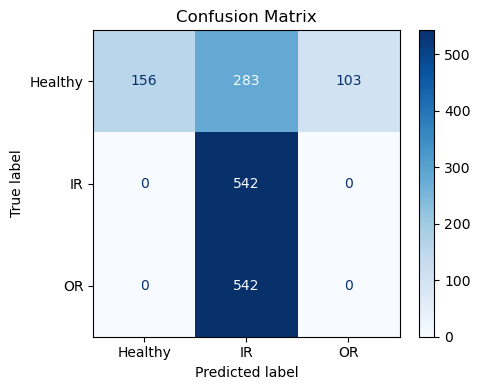

In [10]:
clf = xgb.XGBClassifier(early_stopping_rounds=6, max_depth=3, learning_rate=0.1)
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)])

print()
print(f"Test set accuracy: {clf.score(X_test, y_test)*100:.2f}%")

plot_confusion_matrix(clf, X_test, y_test)

### Support Vector Machine (SVM)

Support vector machines are a classic method for classification. We will use the [Support Vector Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) (since we have more than 2 classes) from Scikit-learn.


Test set accuracy: 34.13%


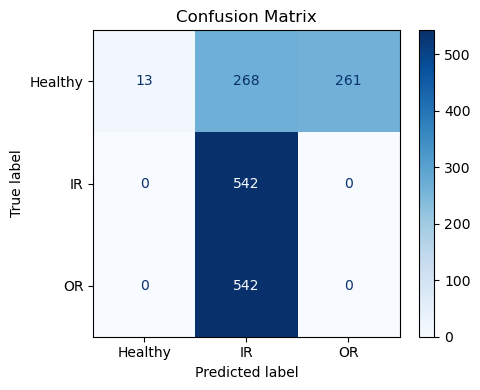

In [11]:
from sklearn.svm import SVC

clf = SVC(kernel="linear", C=1)
clf.fit(X_train, y_train)

acc = clf.score(X_test, y_test)
print(f"Test set accuracy: {acc*100:.2f}%")

plot_confusion_matrix(clf, X_test, y_test)

### Multilayer Perceptron (MLP)

[MLPs](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) are the first step towards deep learning. MLPs can be constructed with other more deep learning oriented libraries, such as PyTorch or TensorFlow, but Scikit-learn also provides an easy way to make them.

In the cell below, use the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) to make an MLP with two hidden layers sized 32 and 8 (or whatever you feel like) and early stopping after 10 batches of no improvement.

_Run the cell multiple times to see how the results change_


Test set accuracy: 47.05%


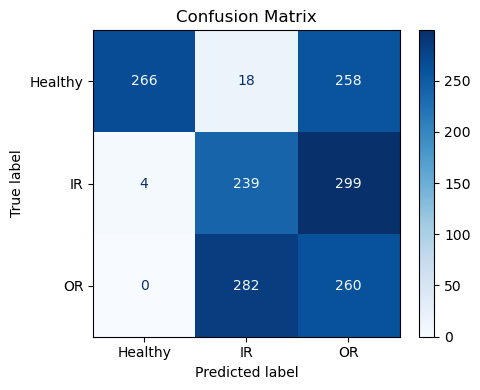

In [12]:
from sklearn.neural_network import MLPClassifier

# CODE HERE: Define an MLPClassifier with early stopping and a reasonable
# architecture (e.g. [32, 8]) for this problem
# Do not set ´random_seed` to any number!
clf = MLPClassifier(
    hidden_layer_sizes=(32, 8),
    learning_rate="adaptive",
    early_stopping=True,
    n_iter_no_change=10,
)
clf.fit(X_train, y_train)

acc = clf.score(X_test, y_test)
print(f"Test set accuracy: {acc*100:.2f}%")

plot_confusion_matrix(clf, X_test, y_test)

Deep learning methods, or more specifically methods using stochastic gradient decent, can get very different results from one training run to another. Because of this, it is important to report the average of multiple runs and the standard deviation to show that the results weren't due to good luck.


In [13]:
mlp_results = []
# CODE HERE: How many repetitions do you think are enough?
for i in range(10):
    clf = clf = MLPClassifier(
        hidden_layer_sizes=(32, 8),
        learning_rate="adaptive",
        early_stopping=True,
        n_iter_no_change=10,
    )
    clf.fit(X_train, y_train)

    acc = clf.score(X_test, y_test)
    mlp_results.append(acc)

print(
    f"Test set accuracy: {np.mean(mlp_results)*100:.2f}% ± {np.std(mlp_results)*100:.2f}%"
)
print(f"Minimum accuracy: {np.min(mlp_results)*100:.2f}%")
print(f"Maximum accuracy: {np.max(mlp_results)*100:.2f}%")

Test set accuracy: 52.54% ± 7.74%
Minimum accuracy: 34.62%
Maximum accuracy: 62.55%


## Deep learning version

One advantage deep learning methods have is the ability to make use of raw data (e.g. time-series or images). This reduces the need for manual feature engineering, which is beneficial because it is not always clear what are the best features to use.

In the cells below, you have the possibility to run two different models. The first is [ZoomCNN](https://doi.org/10.1016/j.ymssp.2023.110865), which is built to imitate how traditional signal analysis methods work. The next is [WDCNN](https://doi.org/10.3390/s17020425), an older but still quite widely used benchmark CNN method for condition monitoring.

For a tutorial on how to make training loops for DL models, see [here](https://wandb.ai/wandb_fc/tips/reports/How-To-Write-Efficient-Training-Loops-in-PyTorch--VmlldzoyMjg4OTk5?galleryTag=pytorch).


In [14]:
## Do not edit this cell

# Create PyTorch dataloaders from the previous data splits

dataloader_train = torch.utils.data.DataLoader(
    list(zip(torch.Tensor(X_train_raw), torch.Tensor(y_train))),
    shuffle=True,
    batch_size=32,
)
dataloader_test = torch.utils.data.DataLoader(
    list(zip(torch.Tensor(X_test_raw), torch.Tensor(y_test))), batch_size=64
)

In [15]:
from torch_models import WDCNN, ZoomCNN

torch.manual_seed(1)  # For demo only!

# HERE: You can choose which model to use
# model = WDCNN()
model = ZoomCNN()


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

# Epochs
for epoch in range(5):

    # Training #

    for i, (X_batch, y_batch) in enumerate(dataloader_train):
        model.train()

        # Add channel dimension and convert to float
        X_batch = X_batch.unsqueeze(1).float()
        y_batch = y_batch.long()

        # Reset gradients and set model to training mode

        # Forward Pass
        y_hat = model(X_batch)

        # Compute Loss and Perform Back-propagation
        loss = loss_fn(y_hat, y_batch)
        loss.backward()

        # Update Optimizer
        optimizer.step()

        # Validation
        if i % 20 == 0:
            print(f"Epoch {epoch+1} | Batch {i+1: <2} | Loss: {loss.item():.8f}")

        # Reset
        optimizer.zero_grad()
        torch.cuda.empty_cache()

    # Validation #

    loss_validation = 0
    acc_validation = 0
    for i, (X_batch, y_batch) in enumerate(dataloader_test):
        model.eval()

        # Add channel dimension and convert to float
        X_batch = X_batch.unsqueeze(1).float()
        y_batch = y_batch.long()

        # Forward Pass
        with torch.no_grad():
            y_hat = model(X_batch)

        # Compute Loss and Perform Back-propagation
        loss = loss_fn(y_hat, y_batch)
        loss_validation += loss.item()
        acc_validation += (y_hat.argmax(dim=1) == y_batch).float().mean().item()

    print(
        f"   Epoch {epoch+1} | Validation Loss: {loss_validation:.8f} | Validation Accuracy: {acc_validation / len(dataloader_test) * 100:.2f}%"
    )

Epoch 1 | Batch 1  | Loss: 1.09120786
Epoch 1 | Batch 21 | Loss: 1.06201017
Epoch 1 | Batch 41 | Loss: 0.71493053
   Epoch 1 | Validation Loss: 32.60409155 | Validation Accuracy: 45.91%
Epoch 2 | Batch 1  | Loss: 0.83423340
Epoch 2 | Batch 21 | Loss: 0.36733553
Epoch 2 | Batch 41 | Loss: 0.05058618
   Epoch 2 | Validation Loss: 18.00808907 | Validation Accuracy: 83.41%
Epoch 3 | Batch 1  | Loss: 0.16898148
Epoch 3 | Batch 21 | Loss: 0.45343855
Epoch 3 | Batch 41 | Loss: 0.03079572
   Epoch 3 | Validation Loss: 1.87499479 | Validation Accuracy: 96.57%
Epoch 4 | Batch 1  | Loss: 0.01134544
Epoch 4 | Batch 21 | Loss: 0.00114266
Epoch 4 | Batch 41 | Loss: 0.00035482
   Epoch 4 | Validation Loss: 3.67431106 | Validation Accuracy: 95.07%
Epoch 5 | Batch 1  | Loss: 0.00031822
Epoch 5 | Batch 21 | Loss: 0.00044149
Epoch 5 | Batch 41 | Loss: 0.00041545
   Epoch 5 | Validation Loss: 3.60579358 | Validation Accuracy: 95.13%
